# 1. Data Cleaning



In [2]:
import pandas as pd
import numpy as np
import re

**HELPER FUNCTIONS**

In [17]:
def parse_int(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace("\xa0", " ").replace(" ", "")
    nums = re.findall(r"\d+", s)
    if not nums:
        return np.nan
    return int("".join(nums))

def parse_float(x):
    if pd.isna(x):
          return np.nan
    try:
        first = str(x).split()[0].replace(",", ".")
        return float(first)
    except:
        return np.nan


def parse_engine_liters(x):
    if pd.isna(x):
        return np.nan

    try:
        val, unit = str(x).split()
        val = float(val.replace(",", "."))
    except:
        return np.nan

    unit = unit.lower()
    if unit.startswith("l"):
        return val
    if unit.startswith("cm"):
        return round(val / 1000, 1)

    return np.nan

def parse_power(x):
    if pd.isna(x):
        return np.nan

    try:
        value, unit = str(x).split()
        value = float(value.replace(",", "."))
    except:
        return np.nan

    unit = unit.lower()

    if unit == "kw":
        return int(round(value))

    if unit == "hj":
        return int(round(value * 0.7355))

    return np.nan

**READING IN DATA**

In [18]:
csv_files = [
    "../../data/raw/auto24_data(1st batch).csv",
    "../../data/raw/auto24_data(2nd batch).csv",
    "../../data/raw/auto24_data(3rd batch).csv",
    "../../data/raw/auto24_data(last batch).csv",
]

dfs = []
for f in csv_files:
    print("Reading:", f)
    if f.endswith("(2nd batch).csv"):
      df_part = pd.read_csv(
          f,
          usecols=range(276),
          on_bad_lines="skip"
      )

    else:
      df_part = pd.read_csv(
          f,
          engine="python",       # more tolerant parser
          on_bad_lines="skip"    # skip rows with wrong number of columns
    )
    print(f, "shape:", df_part.shape)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

print("Rows after merge:", df.shape)

Reading: ../../data/raw/auto24_data(1st batch).csv
../../data/raw/auto24_data(1st batch).csv shape: (4000, 272)
Reading: ../../data/raw/auto24_data(2nd batch).csv
../../data/raw/auto24_data(2nd batch).csv shape: (4000, 276)
Reading: ../../data/raw/auto24_data(3rd batch).csv


/var/folders/hs/8nm59gsn1b9__1001dmqwfkr0000gn/T/ipykernel_53137/328497833.py:12: DtypeWarning: Columns (257,262,263) have mixed types. Specify dtype option on import or set low_memory=False.
  df_part = pd.read_csv(


../../data/raw/auto24_data(3rd batch).csv shape: (3000, 275)
Reading: ../../data/raw/auto24_data(last batch).csv
../../data/raw/auto24_data(last batch).csv shape: (309, 244)
Rows after merge: (11309, 521)


**REMOVE DUPLICANTS**

In [19]:
if "Link" in df.columns:
    df = df.drop_duplicates(subset="Link")

print("Rows after removing duplicates:", df.shape)

Rows after removing duplicates: (10964, 521)


**COMBINING COLUMNS**

In [20]:
df_copy = df.copy()
# mitu veergu enne merge'i

cols = [
    ["kesklukustus","kesklukustus (puldiga)"],
    ["isofix lasteistme kinnitus", "isofix lasteistme kinnitus (ees)", "isofix lasteistme kinnitus (taga)", "isofix lasteistme kinnitus (ees, taga)"],
    ["xenon", "xenon (lähituled)", "xenon (kaugtuled)", "xenon (lähituled, kaugtuled)"],
    ["led", 'led (päevatuled)', 'led (päevatuled, tagatuled)', 'led (päevatuled, tagatuled, lähituled)',
     'led (päevatuled, tagatuled, lähituled, kaugtuled)', 'led (tagatuled)', 'led (tagatuled, lähituled)',
    'led (tagatuled, lähituled, kaugtuled)', 'led (lähituled)', 'led (lähituled, kaugtuled)', 'led (kaugtuled)'],
    ["udutuled", 'udutuled (eesmised)', 'udutuled (eesmised, tagumine)', 'udutuled (tagumine)'],
    ['udutuled (kurvitule funktsiooniga)', 'udutuled (tagumine, kurvitule funktsiooniga)', 'udutuled (eesmised, tagumine, kurvitule funktsiooniga)'],
    ["reguleeritav roolisammas", 'reguleeritav roolisammas (kõrgus ja sügavus)'],
    ['reguleeritav roolisammas (elektriliselt)', 'reguleeritav roolisammas (kõrgus ja sügavus, elektriliselt)','reguleeritav roolisammas (kõrgus ja sügavus, elektriliselt, mäluga)',
    'reguleeritav roolisammas (elektriliselt, mäluga)', 'reguleeritav roolisammas (mäluga)'],
    ["navigatsiooniseade", 'navigatsiooniseade (kaardiga)', 'navigatsiooniseade (kaardiga, hääljuhtimisega)', 'navigatsiooniseade (hääljuhtimisega)'],
    ["jalamatid", 'jalamatid (tekstiilist)', 'jalamatid (tekstiilist, kummist)', 'jalamatid (tekstiilist, kummist, veluurist)',
    'jalamatid (kummist)', 'jalamatid (kummist, veluurist)', 'jalamatid (veluurist)'],
    ["topsihoidjad", "topsihoidjad (ees, taga)", "topsihoidjad (taga)", "topsihoidjad (ees)"],
    ["istmed reguleeritava kõrgusega", "istmed reguleeritava kõrgusega (juhiiste, kõrvalistuja iste)", "istmed reguleeritava kõrgusega (juhiiste)", "istmed reguleeritava kõrgusega (kõrvalistuja iste)"],
    ["käetugi ees", "käetugi ees (laekaga)"],
    ["käetugi taga", "käetugi taga (laekaga)"],
    ["elektrilised välispeeglid", 'elektrilised välispeeglid (soojendusega)','elektrilised välispeeglid (soojendusega, kokkuklapitavad)','elektrilised välispeeglid (kokkuklapitavad)'],
    ['elektrilised välispeeglid (mäluga)', 'elektrilised välispeeglid (soojendusega, kokkuklapitavad, mäluga)','elektrilised välispeeglid (kokkuklapitavad, mäluga)'],
    ["pakiruumi avamine elektriliselt", "pakiruumi avamine elektriliselt (puldist)"],
    ["pakiruumi avamine elektriliselt (jalaviipega)", "pakiruumi avamine elektriliselt (puldist, jalaviipega)"],
    ["rulookardin tagaaknal", "rulookardin tagaaknal (elektriline)"],
    ["automaatselt tumenevad peeglid", "automaatselt tumenevad peeglid (sees, väljas)", "automaatselt tumenevad peeglid (sees)", "automaatselt tumenevad peeglid (väljas)", "parkimisandurid", "parkimisandurid (ees, taga)"],
    ["reguleeritav vedrustus",'reguleeritav vedrustus (elektriliselt)', 'reguleeritav vedrustus (elektriliselt, jäikus)','reguleeritav vedrustus (elektriliselt, jäikus, kõrgus)', 'reguleeritav vedrustus (jäikus)',
    'reguleeritav vedrustus (jäikus, kõrgus)', 'reguleeritav vedrustus (kõrgus)'],
    ["pagasikate", "pagasikate (automaatne)"],
    ["veokonks", "veokonks (teisaldatav)"],
    ["veokonks (elektriline)", "veokonks (elektriline, teisaldatav)"]
    ]
for c in cols:
  main_column = c[0]
  df_copy[main_column] = df_copy[c].fillna(0).astype(int).any(axis=1).astype(int)
  df_copy = df_copy.drop(columns=c[1:])



print("Size before: ", df.shape, "\nSize after: ", df_copy.shape)
df = df_copy



Size before:  (10964, 521) 
Size after:  (10964, 455)


**ADDON PROCESSING**

In [21]:
#Identify addon columns
col_list = list(df.columns)
start_idx = col_list.index("abs pidurid")
end_idx = col_list.index("Liik")
addon_cols = col_list[start_idx:end_idx]

for c in addon_cols:
    df[c] = df[c].notna().astype(int)

**DROPING UNNECESSARY COLUMNS**

In [22]:
before = df.shape[1]
last_col = col_list.index("sildade arv")
df = df.iloc[:, :last_col + 1]
after = df.shape[1]
print("Columns before:", before, "\tColumns after:", after)
print("Removed ", before - after, " columns.")

Columns before: 455 	Columns after: 189
Removed  266  columns.


In [23]:
df.columns = df.columns.str.strip().str.replace("\xa0", "", regex=False)

**CLEAN KEY COLUMNS**

In [24]:
# Numeric columns
shape_before = df.shape
df["price"] = df["Hind"].apply(parse_int)
df["mileage_km"] = df["Läbisõidumõõdiku näit"].apply(parse_int)
df["reg_year"] = df["Esmane reg"].astype(str).str.extract(r"(\d{4})").astype(float)
df["engine_l"] = df["mootori maht"].apply(parse_engine_liters)
df["power_kw"] = df["võimsus"].apply(parse_power)
df["top_speed"] = df["tippkiirus"].apply(parse_int)
df["fuel_cons_city"] = df["- linnas"].apply(parse_float)
df["fuel_cons_highway"] = df["- maanteel"].apply(parse_float)
df["fuel_cons_avg"] = df["- keskmine"].apply(parse_float)
if "istekohti" in df.columns:
    df["seats"] = df["istekohti"].astype(float)
if "uste arv" in df.columns:
    df["doors"] = df["uste arv"].astype(float)

# Text columns to one-hot vectors
df["Mark"] = df["Mark"].str.strip()
df = pd.get_dummies(df, columns=["Mark"], prefix="make")
df = pd.get_dummies(df, columns=["Liik"], prefix="type")
df["Keretüüp"] = df["Keretüüp"].str.strip().str.split().str[0]
df = pd.get_dummies(df, columns=["Keretüüp"], prefix="bodytype")
df = pd.get_dummies(df, columns=["Kütus"], prefix="fuel")
df = pd.get_dummies(df, columns=["Vedav sild"], prefix="drivetrain")
df["Käigukast"] = df["Käigukast"].str.strip().str.split().str[0]
df = pd.get_dummies(df, columns=["Käigukast"], prefix="gearbox")

start = df.columns.get_loc("Esmane reg")
end = df.columns.get_loc("sildade arv")

df = df.drop(columns=df.columns[start : end + 1])
df = df.drop(columns=["Täisnimi"])
shape_after = df.shape
print("Shape before:", shape_before, "\tShape after:", shape_after)

/var/folders/hs/8nm59gsn1b9__1001dmqwfkr0000gn/T/ipykernel_53137/3824207563.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["price"] = df["Hind"].apply(parse_int)
/var/folders/hs/8nm59gsn1b9__1001dmqwfkr0000gn/T/ipykernel_53137/3824207563.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mileage_km"] = df["Läbisõidumõõdiku näit"].apply(parse_int)
/var/folders/hs/8nm59gsn1b9__1001dmqwfkr0000gn/T/ipykernel_53137/3824207563.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

Shape before: (10964, 189) 	Shape after: (10964, 283)


In [25]:
rare_cols = [c for c in df.columns if df[c].dtype != "object" and df[c].sum() < 10]
df.drop(columns=rare_cols, inplace=True)

**FILTER BROKEN ROWS**

In [26]:
print("=== DEBUG: BEFORE FILTERING ===")
print("Total rows before filtering:", df.shape[0])

print("Missing price:", df["price"].isna().sum())
print("Missing mileage_km:", df["mileage_km"].isna().sum())
print("Missing reg_year:", df["reg_year"].isna().sum())
print("Missing power_kw:", df["power_kw"].isna().sum())

print("Price min/max:", df["price"].min(), df["price"].max())
print("Mileage min/max:", df["mileage_km"].min(), df["mileage_km"].max())
print("Year min/max:", df["reg_year"].min(), df["reg_year"].max())
print("Power min/max", df["power_kw"].min(), df["power_kw"].max())

=== DEBUG: BEFORE FILTERING ===
Total rows before filtering: 10964
Missing price: 4
Missing mileage_km: 325
Missing reg_year: 28
Missing power_kw: 171
Price min/max: 340.0 579000.0
Mileage min/max: 1.0 3200000.0
Year min/max: 1949.0 2025.0
Power min/max 6.0 750.0


In [27]:
before = df.shape[0]

df = df[
    df["price"].notna() &
    df["mileage_km"].notna() &
    df["reg_year"].notna() &
    df["power_kw"].notna()

]

df = df[(df["reg_year"] >= 1990) & (df["reg_year"] <= 2025)]
df = df[(df["mileage_km"] >= 0) & (df["mileage_km"] <= 800000)]
df = df[(df["price"] >= 300) & (df["price"] <= 300000)]

after = df.shape[0]

print(f"Removed {before - after} invalid rows.")
print("Remaining rows:", after)

Removed 605 invalid rows.
Remaining rows: 10359


**FEATURE ENGINEERING**

In [28]:


CURRENT_YEAR = 2025
df["car_age"] = CURRENT_YEAR - df["reg_year"]
df.loc[df["car_age"] < 0, "car_age"] = np.nan

df["price_per_km"] = df["price"] / df["mileage_km"].replace({0: np.nan})
df["price_per_kw"] = df["price"] / df["power_kw"].replace({0: np.nan})
df["log_price"] = np.log1p(df["price"])

# SAVE

df.to_csv("auto24_cleaned.csv", index=False)
print("Saved cleaned dataset as auto24_cleaned.csv")

Saved cleaned dataset as auto24_cleaned.csv


# 2. Model Training

In [19]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

**LIGHTBGM MODEL**

In [25]:
# Read in data 
df = pd.read_csv("../../data/processed/auto24_cleaned.csv")

# Target: train on log_price, evaluate in euros
y_log = df["log_price"]
y_price = df["price"]

# Columns
X = df.drop(
    columns=["price", "log_price", "Link", "Mudel", "price_per_km", "price_per_kw"],
    errors="ignore"
)

# Train / test split
X_train, X_test, y_train_log, y_test_log, y_train_price, y_test_price = train_test_split(
    X, y_log, y_price,
    test_size=0.2,
    random_state=42
)

# Base model
base_lgbm = LGBMRegressor(
    objective="regression",
    n_estimators=800,      
    n_jobs=-1,
    random_state=42
)

# Hyperparameters
param_dist = {
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 10, 20, 30],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8, 0.9],
    "bagging_fraction": [0.7, 0.8, 0.9],
    "bagging_freq": [1, 5, 10],
    "min_child_samples": [5, 10, 20],
}

# RandomizedSearchCV 
search = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_dist,
    n_iter=20,                      
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train_log)

print("\nBest parameters:")
print(search.best_params_)
print("CV MAE:", -search.best_score_)

# Best LGBM model
best_params = search.best_params_

final_lgbm = LGBMRegressor(
    objective="regression",
    n_estimators=5000,    
    n_jobs=-1,
    random_state=42,
    **best_params
)

final_lgbm.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

# Convert log_price back to price
pred_log = final_lgbm.predict(X_test)
pred_price = np.exp(pred_log)

# Metrics
mae = mean_absolute_error(y_test_price, pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
r2 = r2_score(y_test_price, pred_price)

print("\nLightGBM best scores:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
final_lgbm.save_model("../../models/best_lgbm.pkl")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Traceback (most recent call last):
  File "/Users/jaspersuursild/Library/Python/3.11/lib/python/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_comm.py", line 422, in _on_run
    cmd.send(self.sock)
  File "/Users/jaspersuursild/Library/Python/3.11/lib/python/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_net_command.py", line 111, in send
    sock.sendall(("Content-Length: %s\r\n\r\n" % len(as_bytes)).encode("ascii"))
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/jaspersuursild/Library/Python/3.11/lib/python/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_daemon_thread.py", line 53, in run
    self._on_run()
  File "/Users/jaspersuursild/Library/Python/3.11/lib/python/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_comm.py", line 432, in _on_run
    self.py_db.dispose_and_kill_all_pydevd_threads()
  File "/Users/jaspersuu

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 wi

**RANDOMFOREST MODEL**

In [26]:

# Read in data
df = pd.read_csv("../../data/processed/auto24_cleaned.csv")

# Target: train on log_price, evaluate in euros
y_log = df["log_price"]
y_price = df["price"]

# Columns
X = df.drop(
    columns=["price", "log_price", "Link", "Mudel", "price_per_km", "price_per_kw"],
    errors="ignore"
)

# Train / test split
X_train, X_test, y_train_log, y_test_log, y_train_price, y_test_price = train_test_split(
    X, y_log, y_price,
    test_size=0.2,
    random_state=42
)

# Base model
base_rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Hyperparameters
param_dist = {
    "n_estimators": [200, 400, 600, 800],       
    "max_depth": [10, 20, 30, None],           
    "min_samples_split": [2, 4, 8],            
    "min_samples_leaf": [1, 2, 4],             
    "max_features": ["sqrt", "log2", 0.3, 0.5] 
}

# RandomizedSearchCV 
search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=20,                      
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train_log)


print("\nBest parameters:")
print(search.best_params_)
print("CV MAE:", -search.best_score_)

# Best RF model
best_params = search.best_params_

rf_final = RandomForestRegressor(
    **best_params,
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_train, y_train_log)

# Convert log_price back to price
pred_log = rf_final.predict(X_test)
pred_price = np.exp(pred_log)

# Metrics
mae = mean_absolute_error(y_test_price, pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
r2 = r2_score(y_test_price, pred_price)

print("\nRandomForest best results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
rf_final.save_model("../../models/best_lgbm.pkl")


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters:
{'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
CV MAE: 0.17255453891290726

RandomForest best results:
MAE: 2671.4149574799335
RMSE: 6744.306909599244
R2: 0.8993569780030681


In [35]:
# Combined predictions on log scale
rf_pred_log = rf_final.predict(X_test)
lgbm_pred_log = final_lgbm.predict(X_test)

# Log -> euros
rf_pred_price = np.exp(rf_pred_log)
lgbm_pred_price = np.exp(lgbm_pred_log)

w_lgbm = 0.9
w_rf = 0.1

ens_pred_price_w = w_lgbm * lgbm_pred_price + w_rf * rf_pred_price

mae_w = mean_absolute_error(y_test_price, ens_pred_price_w)
rmse_w = np.sqrt(mean_squared_error(y_test_price, ens_pred_price_w))
r2_w = r2_score(y_test_price, ens_pred_price_w)

print("WEIGHTED ENSEMBLE (LGBM 0.6, RF 0.4)")
print("MAE:", mae_w)
print("RMSE:", rmse_w)
print("R2:", r2_w)

[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
WEIGHTED ENSEMBLE (LGBM 0.6, RF 0.4)
MAE: 2379.131021456179
RMSE: 5817.172401345741
R2: 0.9251256805036543


In [37]:
links_test = df.loc[X_test.index, "Link"]
results = pd.DataFrame({
    "Link": links_test,
    "actual_price": y_test_price,
    "pred_price": ens_pred_price_w,   
})

# arvuta absoluutne viga
results["abs_error"] = (results["actual_price"] - results["pred_price"]).abs()

# sortida suure/väikse vea järgi
results = results.sort_values("abs_error", ascending=False)


In [43]:
overpredicted = results[results["pred_price"] > results["actual_price"] + 1000]
overpredicted = results[results["actual_price"] > results["pred_price"] + 10000]
print(overpredicted)

                                        Link  actual_price     pred_price  \
4333  https://www.auto24.ee/soidukid/4118908      182000.0   90677.484408   
4343  https://www.auto24.ee/soidukid/4239223      210676.0  120096.384098   
4366  https://www.auto24.ee/soidukid/4256764      295000.0  204869.802313   
1020  https://www.auto24.ee/soidukid/4262020      165000.0   94180.670860   
4344  https://www.auto24.ee/soidukid/4238765      215000.0  171151.616034   
1018  https://www.auto24.ee/soidukid/4130408      113900.0   76804.081265   
4337  https://www.auto24.ee/soidukid/3969993      199900.0  165882.785078   
4102  https://www.auto24.ee/soidukid/3898795       64900.0   35957.949159   
970   https://www.auto24.ee/soidukid/4230912       77000.0   51666.975148   
4284  https://www.auto24.ee/soidukid/4237755      109900.0   84802.959682   
4230  https://www.auto24.ee/soidukid/4140256       89900.0   69607.114886   
4237  https://www.auto24.ee/soidukid/4261597       89990.0   70417.198352   

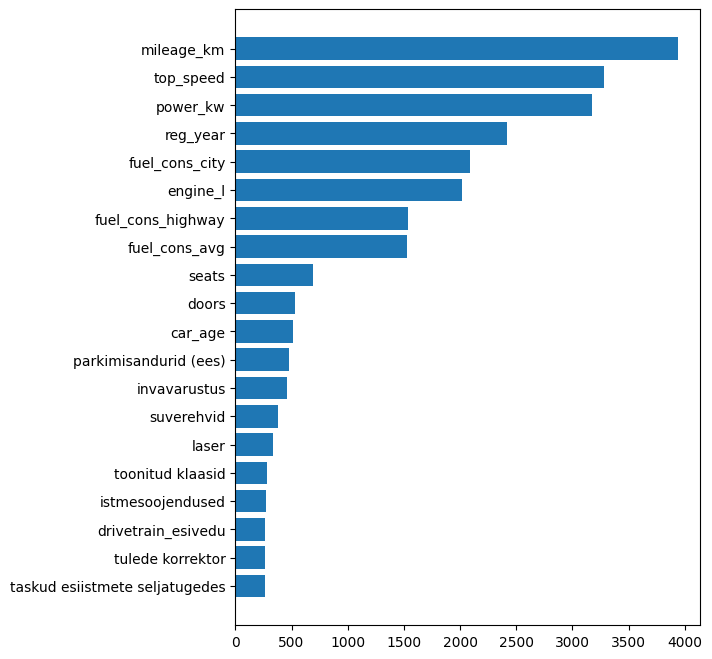

In [44]:
imps = final_lgbm.feature_importances_
idx = np.argsort(imps)[-20:]

plt.figure(figsize=(6, 8))
plt.barh(np.array(X_train.columns)[idx], imps[idx])
plt.show()

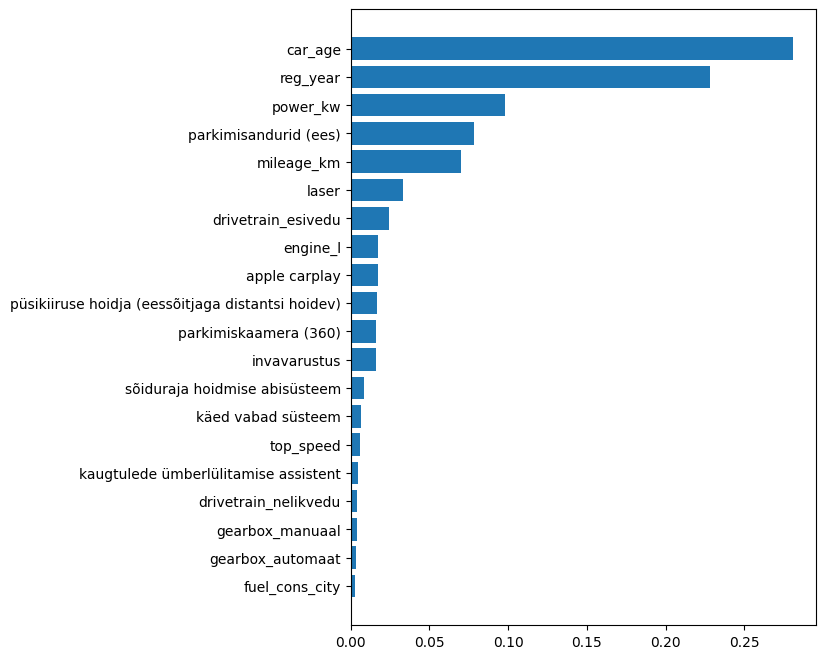

In [45]:
imps = rf_final.feature_importances_
idx = np.argsort(imps)[-20:]

plt.figure(figsize=(6, 8))
plt.barh(np.array(X_train.columns)[idx], imps[idx])
plt.show()